In [1]:
import torch as t
import matplotlib.pyplot as plt

In [2]:
# How to represent numerical data in a computer?
# What are images?

In [3]:
#rgb values
black = (0, 0, 0)
red = (255, 0, 0)
green = (0, 255, 0)
blue = (0, 0, 255)

In [4]:
img = t.tensor(
    [
        [black, red],
        [blue, green]
    ]
)
img

tensor([[[  0,   0,   0],
         [255,   0,   0]],

        [[  0,   0, 255],
         [  0, 255,   0]]])

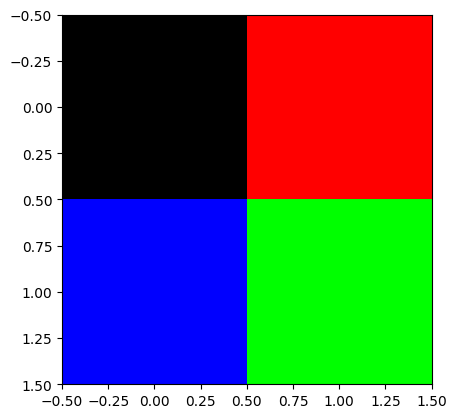

In [5]:
plt.imshow(img)
plt.show()

In [6]:
height = 256
width = 256
rand_img = t.randint(0, 256, (height, width, 3))
rand_img.shape

torch.Size([256, 256, 3])

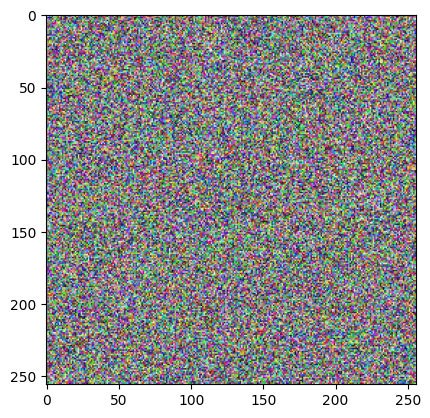

In [7]:
plt.imshow(rand_img)
plt.show()

In [8]:
# What are deep learning models? And how can they learn?

In [9]:
data = t.rand(100, 4)
target = t.rand(100, 1)

In [10]:
weight = t.rand(1, 4, requires_grad=True)
weight

tensor([[0.4521, 0.9916, 0.2388, 0.9954]], requires_grad=True)

In [11]:
def perceptron(data, target, weight):
    pred = (data * weight).sum(-1, keepdim=True)
    return ((pred - target) ** 2).mean()

In [12]:
lr = 0.01
def update(weight):
    weight = weight.detach() - lr * weight.grad.detach()
    weight.requires_grad=True
    return weight

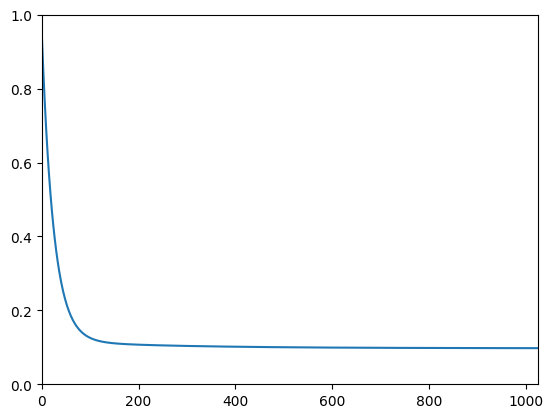

In [13]:
lst = []
weight = t.rand(1, 4, requires_grad=True)
for i in range(1024):
    loss = perceptron(data, target, weight)
    loss.backward()
    weight = update(weight)
    lst.append(loss.item())
plt.plot(list(range(1024)), lst)
plt.axis([0, 1024, 0.0, 1.0])
plt.show()

In [14]:
# Padding

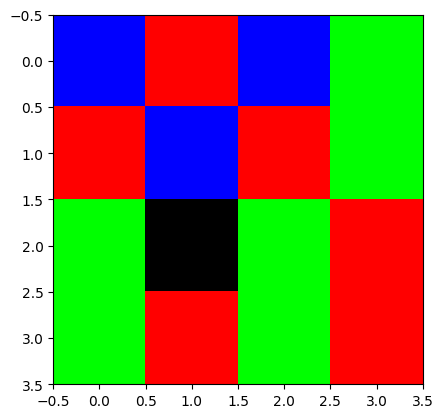

In [15]:
img = t.tensor(
    [
        [blue, red, blue, green],
        [red, blue, red, green],
        [green, black, green, red],
        [green, red, green, red]
    ]
)
plt.imshow(img)
plt.show()

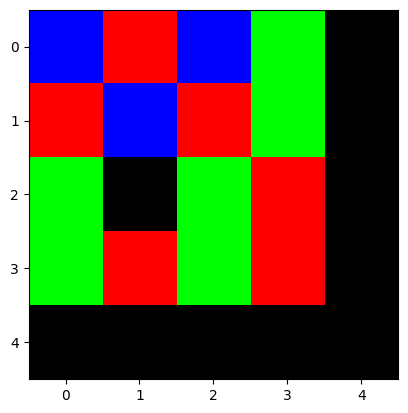

In [16]:
padded_img = t.tensor(
    [
        [blue, red, blue, green, black],
        [red, blue, red, green, black],
        [green, black, green, red, black],
        [green, red, green, red, black],
        [black] * 5,
    ]
)
plt.imshow(padded_img)
plt.show()

In [17]:
first_layer_weight = t.rand(4, 4, requires_grad=True)
first_layer_weight

tensor([[0.2465, 0.4678, 0.1090, 0.5066],
        [0.4077, 0.9753, 0.0024, 0.2293],
        [0.4745, 0.8785, 0.9674, 0.3099],
        [0.5877, 0.5775, 0.4366, 0.2415]], requires_grad=True)

In [18]:
second_layer_weight = t.rand(1, 4, requires_grad=True)
second_layer_weight

tensor([[0.6706, 0.4586, 0.4137, 0.8192]], requires_grad=True)

In [19]:
def multi_layer_perceptron(data, target, first_layer_weight, second_layer_weight):
    first_hidden_representation = (data[..., None] * first_layer_weight.T).sum(-2)
    transf_first_hidden_representation = t.nn.functional.relu(first_hidden_representation)
    pred = (transf_first_hidden_representation * second_layer_weight).sum(-1, keepdim=True)
    return ((pred - target) ** 2).mean()

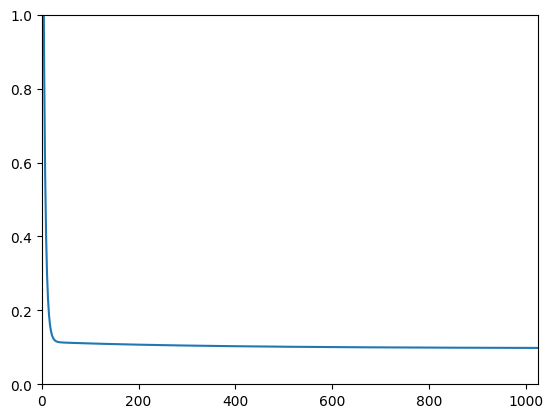

In [20]:
lst = []
first_layer_weight = t.rand(4, 4, requires_grad=True)
second_layer_weight = t.rand(1, 4, requires_grad=True)
for i in range(1024):
    loss = multi_layer_perceptron(data, target, first_layer_weight, second_layer_weight)
    loss.backward()
    first_layer_weight = update(first_layer_weight)
    second_layer_weight = update(second_layer_weight)
    lst.append(loss.item())
plt.plot(list(range(1024)), lst)
plt.axis([0, 1024, 0.0, 1.0])
plt.show()

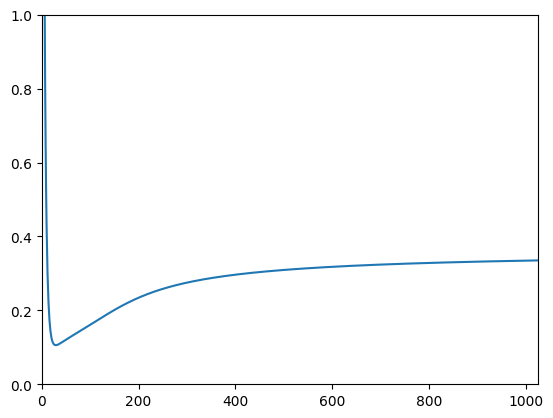

In [21]:
# add weight decay
lst = []
first_layer_weight = t.rand(4, 4, requires_grad=True)
second_layer_weight = t.rand(1, 4, requires_grad=True)
for i in range(1024):
    regression_loss = multi_layer_perceptron(data, target, first_layer_weight, second_layer_weight)
    weight_decay_loss = (first_layer_weight ** 2).sum() + (second_layer_weight ** 2).sum()
    loss = regression_loss + 0.5 * weight_decay_loss
    loss.backward()
    first_layer_weight = update(first_layer_weight)
    second_layer_weight = update(second_layer_weight)
    lst.append(regression_loss.item())
plt.plot(list(range(1024)), lst)
plt.axis([0, 1024, 0.0, 1.0])
plt.show()